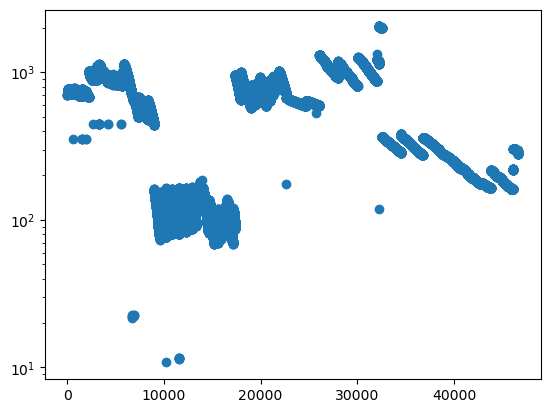

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
data = pd.read_csv("./feeds.csv")

def pickfield(data, field_nr):
    field = data[data[field_nr]>10]
    #field.head()
    
    return field

def plotfield(field_nr):
    field = pickfield(data, field_nr)
    
    ax = plt.gca()
    ax.scatter(x=field["entry_id"], y=field[field_nr])
    ax.set_yscale('log')
plotfield("field6")
# plt.show()

In [4]:
import seaborn as sns
import statsmodels.api as sm  
from statsmodels.formula.api import ols 

def select_range(data, field_nr, start, end):
    field = pickfield(data, field_nr)
    #print(field.head())
    field = field[field["entry_id"] > start]
    field = field[field["entry_id"] < end]
    return field
# field8smol['field8'] = field8smol['field8'].shift(-24) - field8smol['field8']
# field8smol = field8smol[field8smol["entry_id"] % 24 == 0]

# sns.residplot(x='entry_id', y='field8', data=field8smol)
# plt.xlabel("entry id")
# plt.ylabel("Residuals")
# plt.show()

#select_range("field7", 43795,45795)
def residual_graph(field_nr, start, end):

    data_field = select_range(data, field_nr, start, end)
    
    lm = ols(f'{field_nr} ~ entry_id', data=data_field).fit()
    print(lm.summary()) 
    fig = plt.figure(figsize=(14, 8))
    fig = sm.graphics.plot_regress_exog(lm, 'entry_id', fig=fig)  

#residual_graph("field7", 43795 ,45795)
#residual_graph("field7", 43795 ,44795)
# ax1 = plt.gca()
# ax1.scatter(x=field8smol["entry_id"], y=field8smol["field8"])

# plt.show()

In [26]:
#!pip install piecewise-regression
import piecewise_regression
pw_fit = piecewise_regression.Fit(list(field8smol["entry_id"]), list(field8smol["field7"]), n_breakpoints=1)
pw_fit.summary()

pw_fit.plot_data(color="grey", s=20)
# Pass in standard matplotlib keywords to control any of the plots
pw_fit.plot_fit(color="red", linewidth=4)
pw_fit.plot_breakpoints()
pw_fit.plot_breakpoint_confidence_intervals()
plt.xlabel("x")
plt.ylabel("y")
plt.show()
plt.close()

NameError: name 'field8smol' is not defined

Cycle lengths: [1483 1931 1994 1964 2221 1703 2800 1980 2017 3052 2000]


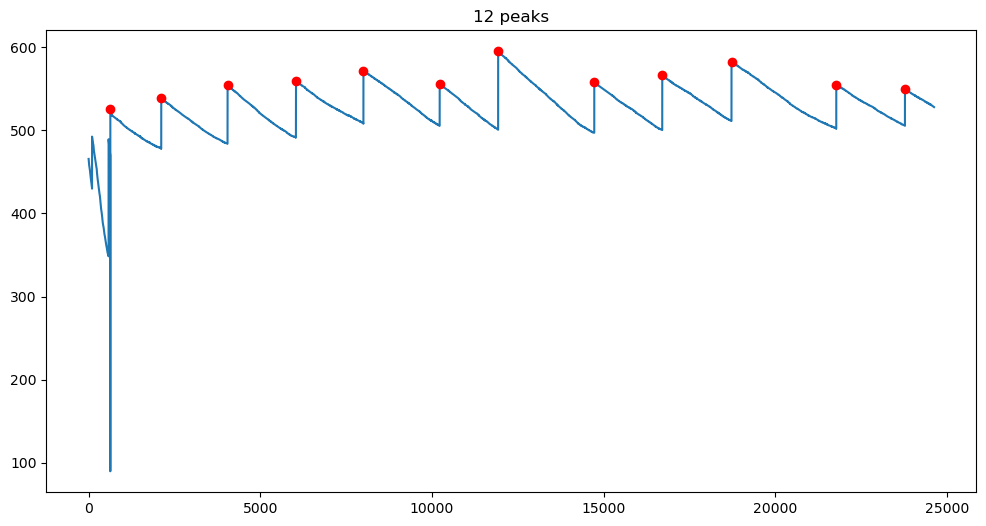

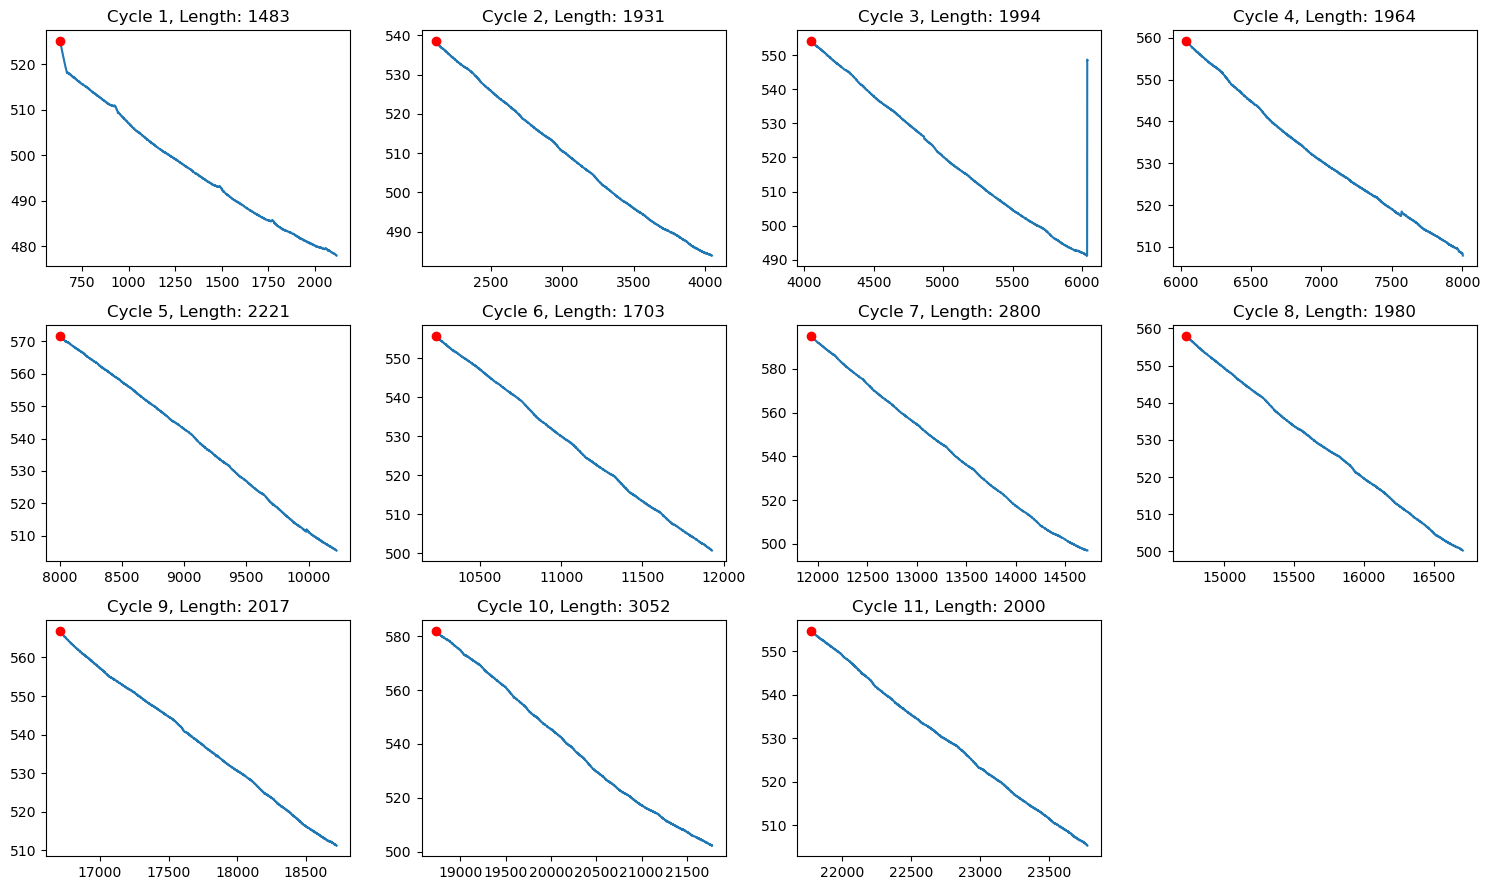

In [2]:
from scipy.signal import find_peaks

y = field7[field7["entry_id"] >22000]["field7"]
y = y.reset_index(drop=True)
x = np.arange(len(y))
#x = field7[field7["entry_id"] >22000]["entry_id"]


peaks, _ = find_peaks(y, distance=1000, prominence=0.5)   # distance prevents false peaks, so does prominence


cycle_lengths = np.diff(peaks)

print("Cycle lengths:", cycle_lengths)
plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.plot(x[peaks], y[peaks], "ro")
plt.title(f"{len(peaks)} peaks")

cycles = len(peaks)-1

if cycles>0:
    n_cols = 4
    n_rows = int(np.ceil(cycles/n_cols))

    plt.figure(figsize=(15,3*n_rows))
    for i in range(cycles):
        start = peaks[i]
        end = peaks[i+1]
        plt.subplot(n_rows, n_cols, i+1)
        plt.plot(x[start:end], y[start:end])
        plt.plot(x[start], y[start], "ro")
        plt.title(f"Cycle {i+1}, Length: {cycle_lengths[i]}")
        
        plt.tight_layout()
plt.show()

0     -0.056557
1     -0.066526
2     -0.106496
3     -0.026465
4      0.253566
         ...   
179    0.048934
180    0.038965
181    0.018996
182    0.119026
183    0.169057
Length: 184, dtype: float64


<Axes: xlabel='entry_id', ylabel='Residuals'>

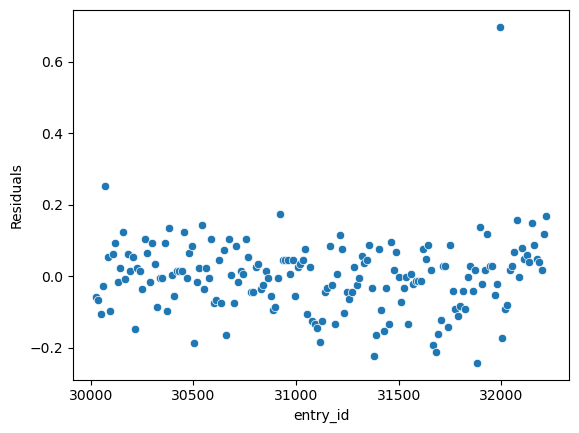

In [151]:

field = select_range(data, "field7",43796, 45796 ) #30023, 32244
field = field[field["entry_id"] % 12 == 0].copy()
field.reset_index(drop=True, inplace=True)
field['field7_diff'] = (field['field7'].shift(-1) - field['field7'])
field.dropna(subset=['field7_diff'], inplace=True)

#sns.scatterplot(x='entry_id', y='field7_diff', data=field)

# x = field["entry_id"]
# y = field["field7_diff"]

# x = sm.add_constant(x)

# model = sm.OLS(y, x)
# results = model.fit()
# print(results.resid)

    
# field["Residuals"] = results.resid
# sns.scatterplot(data = field, x="entry_id", y="Residuals")

<Axes: xlabel='entry_id', ylabel='field7'>

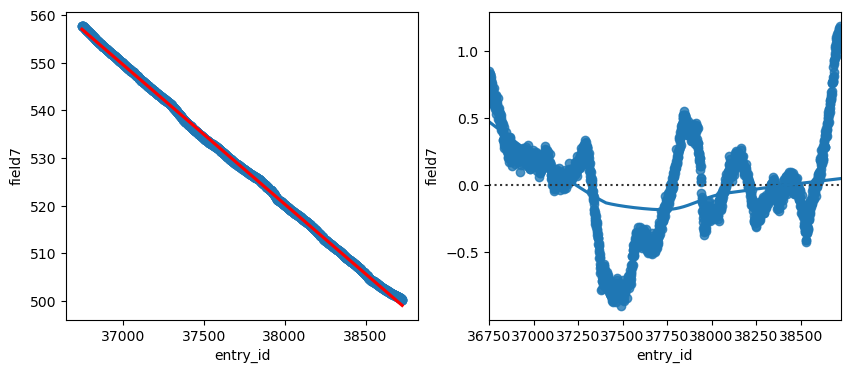

In [157]:
field = select_range(data_5, "field7", 36747, 38727)#data_5, 33947, 36747, "field7") 36747 38727 
field = field[field["entry_id"] % 1 == 0]
# field['field8'] = (field['field8'].shift(-24) - field['field8'])
# field = field[field["entry_id"] % 24 == 0]
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.regplot(x='entry_id', y='field7', data=field, order = 1, line_kws=dict(color="r"), ax=axs[0])
sns.residplot(x='entry_id', y='field7', data=field, ax=axs[1], lowess = True)
# sns.residplot(x='entry_id', y='field8', data=field8smol)
# plt.xlabel("entry id")
# plt.ylabel("Residuals")
# plt.show()

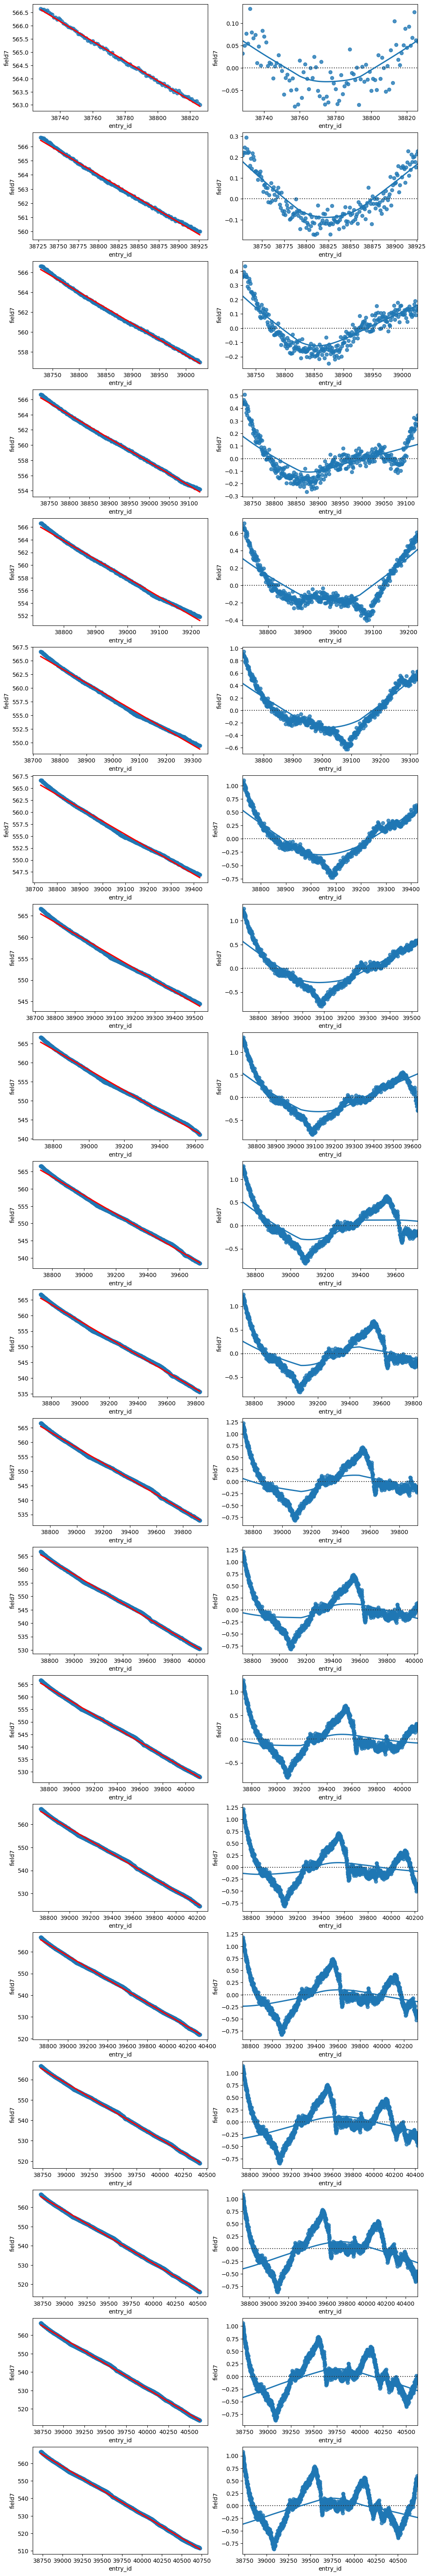

In [217]:
lower = 38727 #30023 40744 36747
upper = 40744 #32244 43796 38727
diff = upper-lower
chunks = 20

fig, axs = plt.subplots(chunks, 2, figsize=(12, chunks*4))
for i in range(chunks):
    chunkdiff = diff//chunks
    currentlower = lower + i*chunkdiff
    currentupper = lower + (i+1)*chunkdiff 
    field = select_range(data, "field7",lower, currentupper)


    sns.regplot(x='entry_id', y='field7', data=field, order = 1, line_kws=dict(color="r"), ax=axs[i,0], ci = None)
    sns.residplot(x='entry_id', y='field7', data=field, order = 1, ax=axs[i, 1], lowess = True)

In [18]:
data_30 = data.iloc[:22673]
data_5 = data.iloc[22673:]

data_30.to_csv("feeds_30.csv", index=False)
data_5.to_csv("feeds_5.csv", index=False)


In [28]:

from astral.sun import sun
from astral import LocationInfo

data_5 = pd.read_csv("feeds_5.csv")

def add_day_night_column(df, timestamp_col, location):
    
    
    # 1. Ensure the timestamp column is in the correct datetime format
    #    This converts your string into a timezone-aware datetime object.
    #    The `+02:00` offset will be handled automatically.
    df['timestamp'] = pd.to_datetime(df[timestamp_col], utc=True).dt.tz_convert(location.timezone)
    
    # 2. Get the unique dates from your data
    df['date'] = df['timestamp'].dt.date
    unique_dates = df['date'].unique()
    
    # 3. Create a lookup map for sunrise/sunset times (the "algorithm")
    #    This is the core optimization: we only calculate once per day.
    sun_times_map = {}
    for date in unique_dates:
        s = sun(location.observer, date=date)
        sun_times_map[date] = {'sunrise': s['sunrise'], 'sunset': s['sunset']}
        
    # 4. Map these times back to your original DataFrame
    df['sunrise'] = df['date'].map(lambda x: sun_times_map[x]['sunrise'])
    df['sunset'] = df['date'].map(lambda x: sun_times_map[x]['sunset'])
    
    # 5. Perform the vectorized comparison
    df['ToD'] = np.where(
        (df['timestamp'] >= df['sunrise']) & (df['timestamp'] < df['sunset']),
        'Day',
        'Night'
    )
    
    # 6. Clean up temporary columns
    df = df.drop(columns=['date', 'sunrise', 'sunset'])
    
    return df

# --- How to Use It ---

# 1. Define your location (Tartu, Estonia)
# You can find coordinates for other cities easily.
loc = LocationInfo(name="Tartu", region="Estonia", timezone="Europe/Tallinn",
                   latitude=58.3780, longitude=26.7290)


data_5 = add_day_night_column(data_5, timestamp_col='created_at', location=loc)

print(data_5["ToD"].value_counts())

ToD
Day      16002
Night     7972
Name: count, dtype: int64


<Axes: xlabel='entry_id', ylabel='field8'>

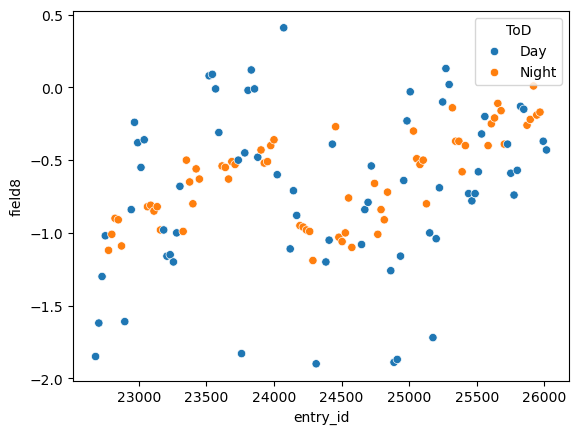

In [51]:


field = select_range(data_5, "field8", 22674, 26050)
field['field8'] = (field['field8'].shift(-24) - field['field8'])
field = field[field["entry_id"] % 24 == 0]
field = field[field["field8"] > -2]
field = field[field["field8"] < 3]


sns.scatterplot(x='entry_id', y='field8', hue="ToD", data=field)

35273 SIIN 1472 545.6


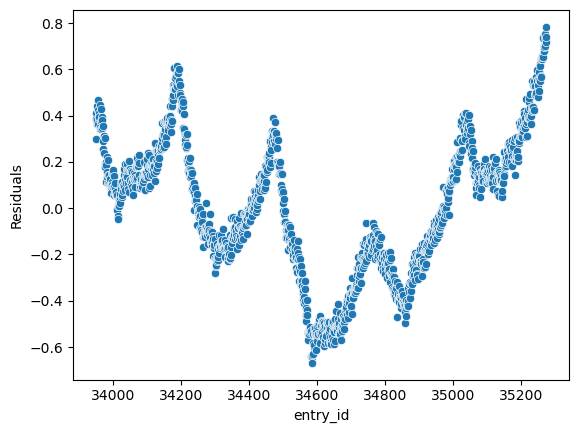

In [180]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
data_5 = pd.read_csv("feeds_5.csv")

def model_avg_residual(data, lower_bound, upper_bound, field_nr):
    broken = False
    lower = lower_bound
    upperlimit = lower + 288
    upper = upper_bound
    
    field = select_range(data, field_nr, lower, upper)
    
    for i in range(upper-upperlimit):
        #print(upperlimit)
        current_field = field[field["entry_id"] < upperlimit].copy()
        #current_field = current_field[current_field["entry_id"]%1 == 0]
        x = current_field["entry_id"]
        y = current_field[field_nr]
      
        
        x = sm.add_constant(x)
        model = sm.GLS(y, x)
        results = model.fit()
        
        # model_lad = smf.quantreg('field7 ~ entry_id', data=data).fit(q=0.5)
    
        current_field["Residuals"] = results.resid
        #print(int(current_field["entry_id"].iloc[0]), )
        
       
        #print(half_max)
    
        poolindeks = len(current_field.index)//2
        #print(poolindeks)
        half_max = current_field[current_field["entry_id"]<(int(current_field["entry_id"].iloc[0])+poolindeks)]["Residuals"].max()
        #sh_min = current_field[current_field["entry_id"]>(int(current_field["entry_id"].iloc[0])+poolindeks)]["Residuals"].min()
            
        half_max_index = current_field[current_field["Residuals"] == half_max]["entry_id"].iloc[0].item()
        
    
        half_max *= 0.25
        # current_field = current_field[current_field["entry_id"] > half_max_index]
        # poolindeks = len(current_field.index)//2
        # x = current_field["entry_id"]
        # y = current_field["field6"]
      
        
        # x = sm.add_constant(x)
        # model = sm.OLS(y, x)
        # results = model.fit()
    
        # current_field["Residuals"] = results.resid
    
        x = 0
        residsum = 0
        count = 0
        
        resids = current_field[current_field["entry_id"]>(int(current_field["entry_id"].iloc[0])+poolindeks)]["Residuals"]
        #already_resids = []
        resids_max = resids.max()
        for resid in resids:
            # if resid == resids_max and resid-sh_min > 2*half_max:
            #     resid = resid -sh_min
            #     broken = True
            #     print(x + int(current_field["entry_id"].iloc[0])+poolindeks, "SIIN", upper-upperlimit, current_field[field_nr].iloc[-1])
            #     break
            # elif len(already_resids) >= 5 and resids_max in already_resids[-5:]:
            #     resid = resid -sh_min
                
            #highest = 
            
            if resid >= 0:
                #already_resids.append(resid)
                residsum += resid
                count += 1
                
                #and count >= 288
                #residsum/count >= half_max and count >= 144 and (upperlimit - (x + int(current_field["entry_id"].iloc[0])+poolindeks)) <= 10
                #residsum > half_max*288 and (upperlimit - (x + int(current_field["entry_id"].iloc[0])+poolindeks)) <= 10
                if residsum/count >= half_max and count >= 288 and (upperlimit - (x + int(current_field["entry_id"].iloc[0])+poolindeks)) <= 10 :
                    broken = True
                    print(x + int(current_field["entry_id"].iloc[0])+poolindeks, "SIIN", upper-upperlimit, current_field[field_nr].iloc[-1])
                    break
            else:
                residsum = 0
                count = 0
            x += 1
        if broken:
            break
        upperlimit += 1
    sns.scatterplot(data = current_field, x="entry_id", y="Residuals")
    if upperlimit != upper:
        return upperlimit
    
model_avg_residual(data_5, 33947, 36747, "field7")
#print(residsum, count, upperlimit)


35369 SIIN 268 503.09


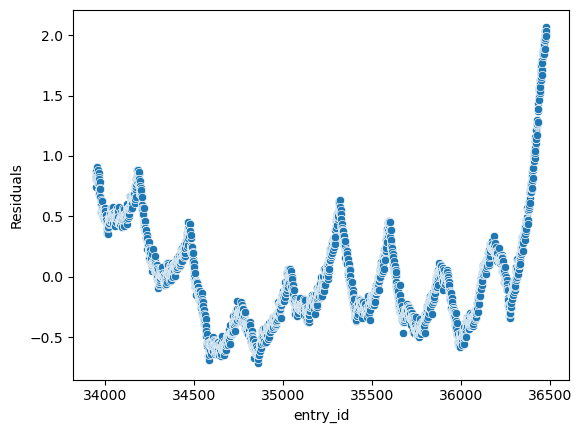

In [179]:
data_5 = pd.read_csv("feeds_5.csv")

def model_zero_points(data, lower_bound, upper_bound, field_nr):
    
    broken = False
    lower = lower_bound
    upperlimit = lower + 288
    upper = upper_bound
    
    field = select_range(data, field_nr, lower, upper)
    
    for i in range(upper-upperlimit):

        current_field = field[field["entry_id"] < upperlimit].copy()
        
        x = current_field["entry_id"]
        y = current_field[field_nr]
        x = sm.add_constant(x)
        model = sm.OLS(y, x)
        results = model.fit()
        current_field["Residuals"] = results.resid
     
        poolindeks = len(current_field.index)//2
        half_max = current_field[current_field["entry_id"]<(int(current_field["entry_id"].iloc[0])+poolindeks)]["Residuals"].max()   
        half_max_index = current_field[current_field["Residuals"] == half_max]["entry_id"].iloc[0].item()
        
        
        positive_current = current_field['Residuals'] > 0

        negative_previous = current_field['Residuals'].shift(1) < 0
        
        transition_points = current_field[positive_current & negative_previous]

        last_transition_index = transition_points["entry_id"].max()
        
        
        x = 0
        residsum = 0
        count = 0
        
        resids = current_field[current_field["entry_id"]>last_transition_index]["Residuals"]
        for resid in resids:

            if resid >= 0:
                residsum += resid
                count += 1

                if upperlimit-last_transition_index > 144 and residsum/count >half_max:
                    broken = True
                    print(x + int(current_field["entry_id"].iloc[0])+poolindeks, "SIIN", upper-upperlimit, current_field[field_nr].iloc[-1])
                    break
            else:
                residsum = 0
                count = 0
            x += 1
        if broken:
            break
        upperlimit += 1
        
    sns.scatterplot(data = current_field, x="entry_id", y="Residuals")
    if upperlimit != upper:
        return upperlimit

model_zero_points(data_5, 33947, 36747, "field7")

<Axes: xlabel='entry_id', ylabel='Residuals'>

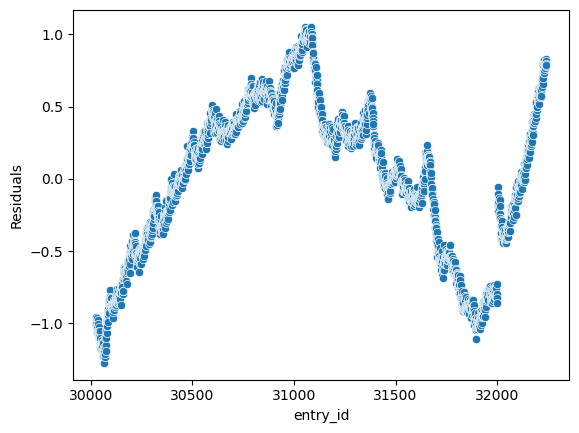

In [182]:
current_data = select_range(data_5, "field7", 30023, 32244)
#model_lad = smf.quantreg('field7 ~ entry_id', data=current_data).fit(q=0.5)
x = current_data["entry_id"]
y = current_data["field7"]
x = sm.add_constant(x)
model = sm.OLS(y, x)
results = model.fit()
current_data["Residuals"] = results.resid
     
#current_data["Residuals"] = model_lad.resid
#current_data['Smoothed'] = current_data['Residuals'].rolling(window=144).mean()
sns.scatterplot(data = current_data, x="entry_id", y="Residuals")

36400 SIIN 347 504.88


36400

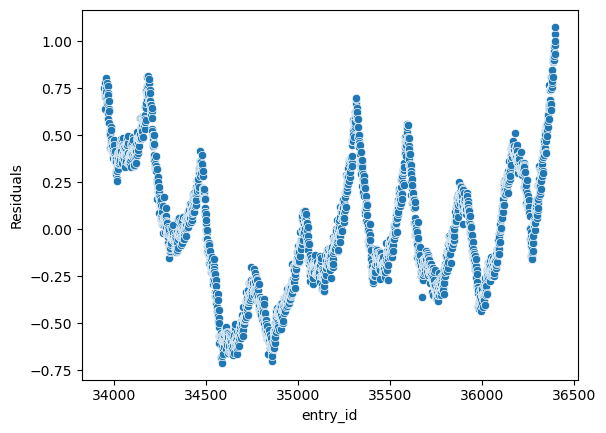

In [199]:
data_5 = pd.read_csv("feeds_5.csv")

def model_cusum(data, lower_bound, upper_bound, field_nr):

    drift = 0.05
    threshold = 85
    broken = False
    lower = lower_bound
    upperlimit = lower + 576
    upper = upper_bound
    
    field = select_range(data, field_nr, lower, upper)
    cusums = []
    for i in range(upper-upperlimit):

        
        current_field = field[field["entry_id"] < upperlimit].copy()
        
        x = current_field["entry_id"]
        y = current_field[field_nr]
        x = sm.add_constant(x)
        model = sm.OLS(y, x)
        results = model.fit()
        current_field["Residuals"] = results.resid
     
        cusum = 0
        resids = current_field[current_field["entry_id"]>upperlimit-288]["Residuals"]
        for resid in resids:

            if resid-drift >= 0:
                cusum += (resid-drift)
                if cusum > threshold :
                    broken = True
                    print( upperlimit, "SIIN", upper-upperlimit, current_field[field_nr].iloc[-1])
                    break
                    
        if broken:
            break
        upperlimit += 1
    sns.scatterplot(data = current_field, x="entry_id", y="Residuals")
    if upperlimit != upper:
        return upperlimit

model_cusum(data_5, 33947, 36747, "field7")

[(1444, 3375), (4207, 5383), (5383, 7349), (7349, 9570), (9570, 11273), (11273, 14073), (14073, 16053), (16053, 18070), (18070, 21122), (21122, 23122)]
24118 26049
25762 siin 287
26881 28057
27961 siin 96
28057 30023
29389 siin 634
30023 32244
32244 33947
33947 36747
36443 siin 304
36747 38727
38691 siin 36
38727 40744
40744 43796
42868 siin 928
43796 45796


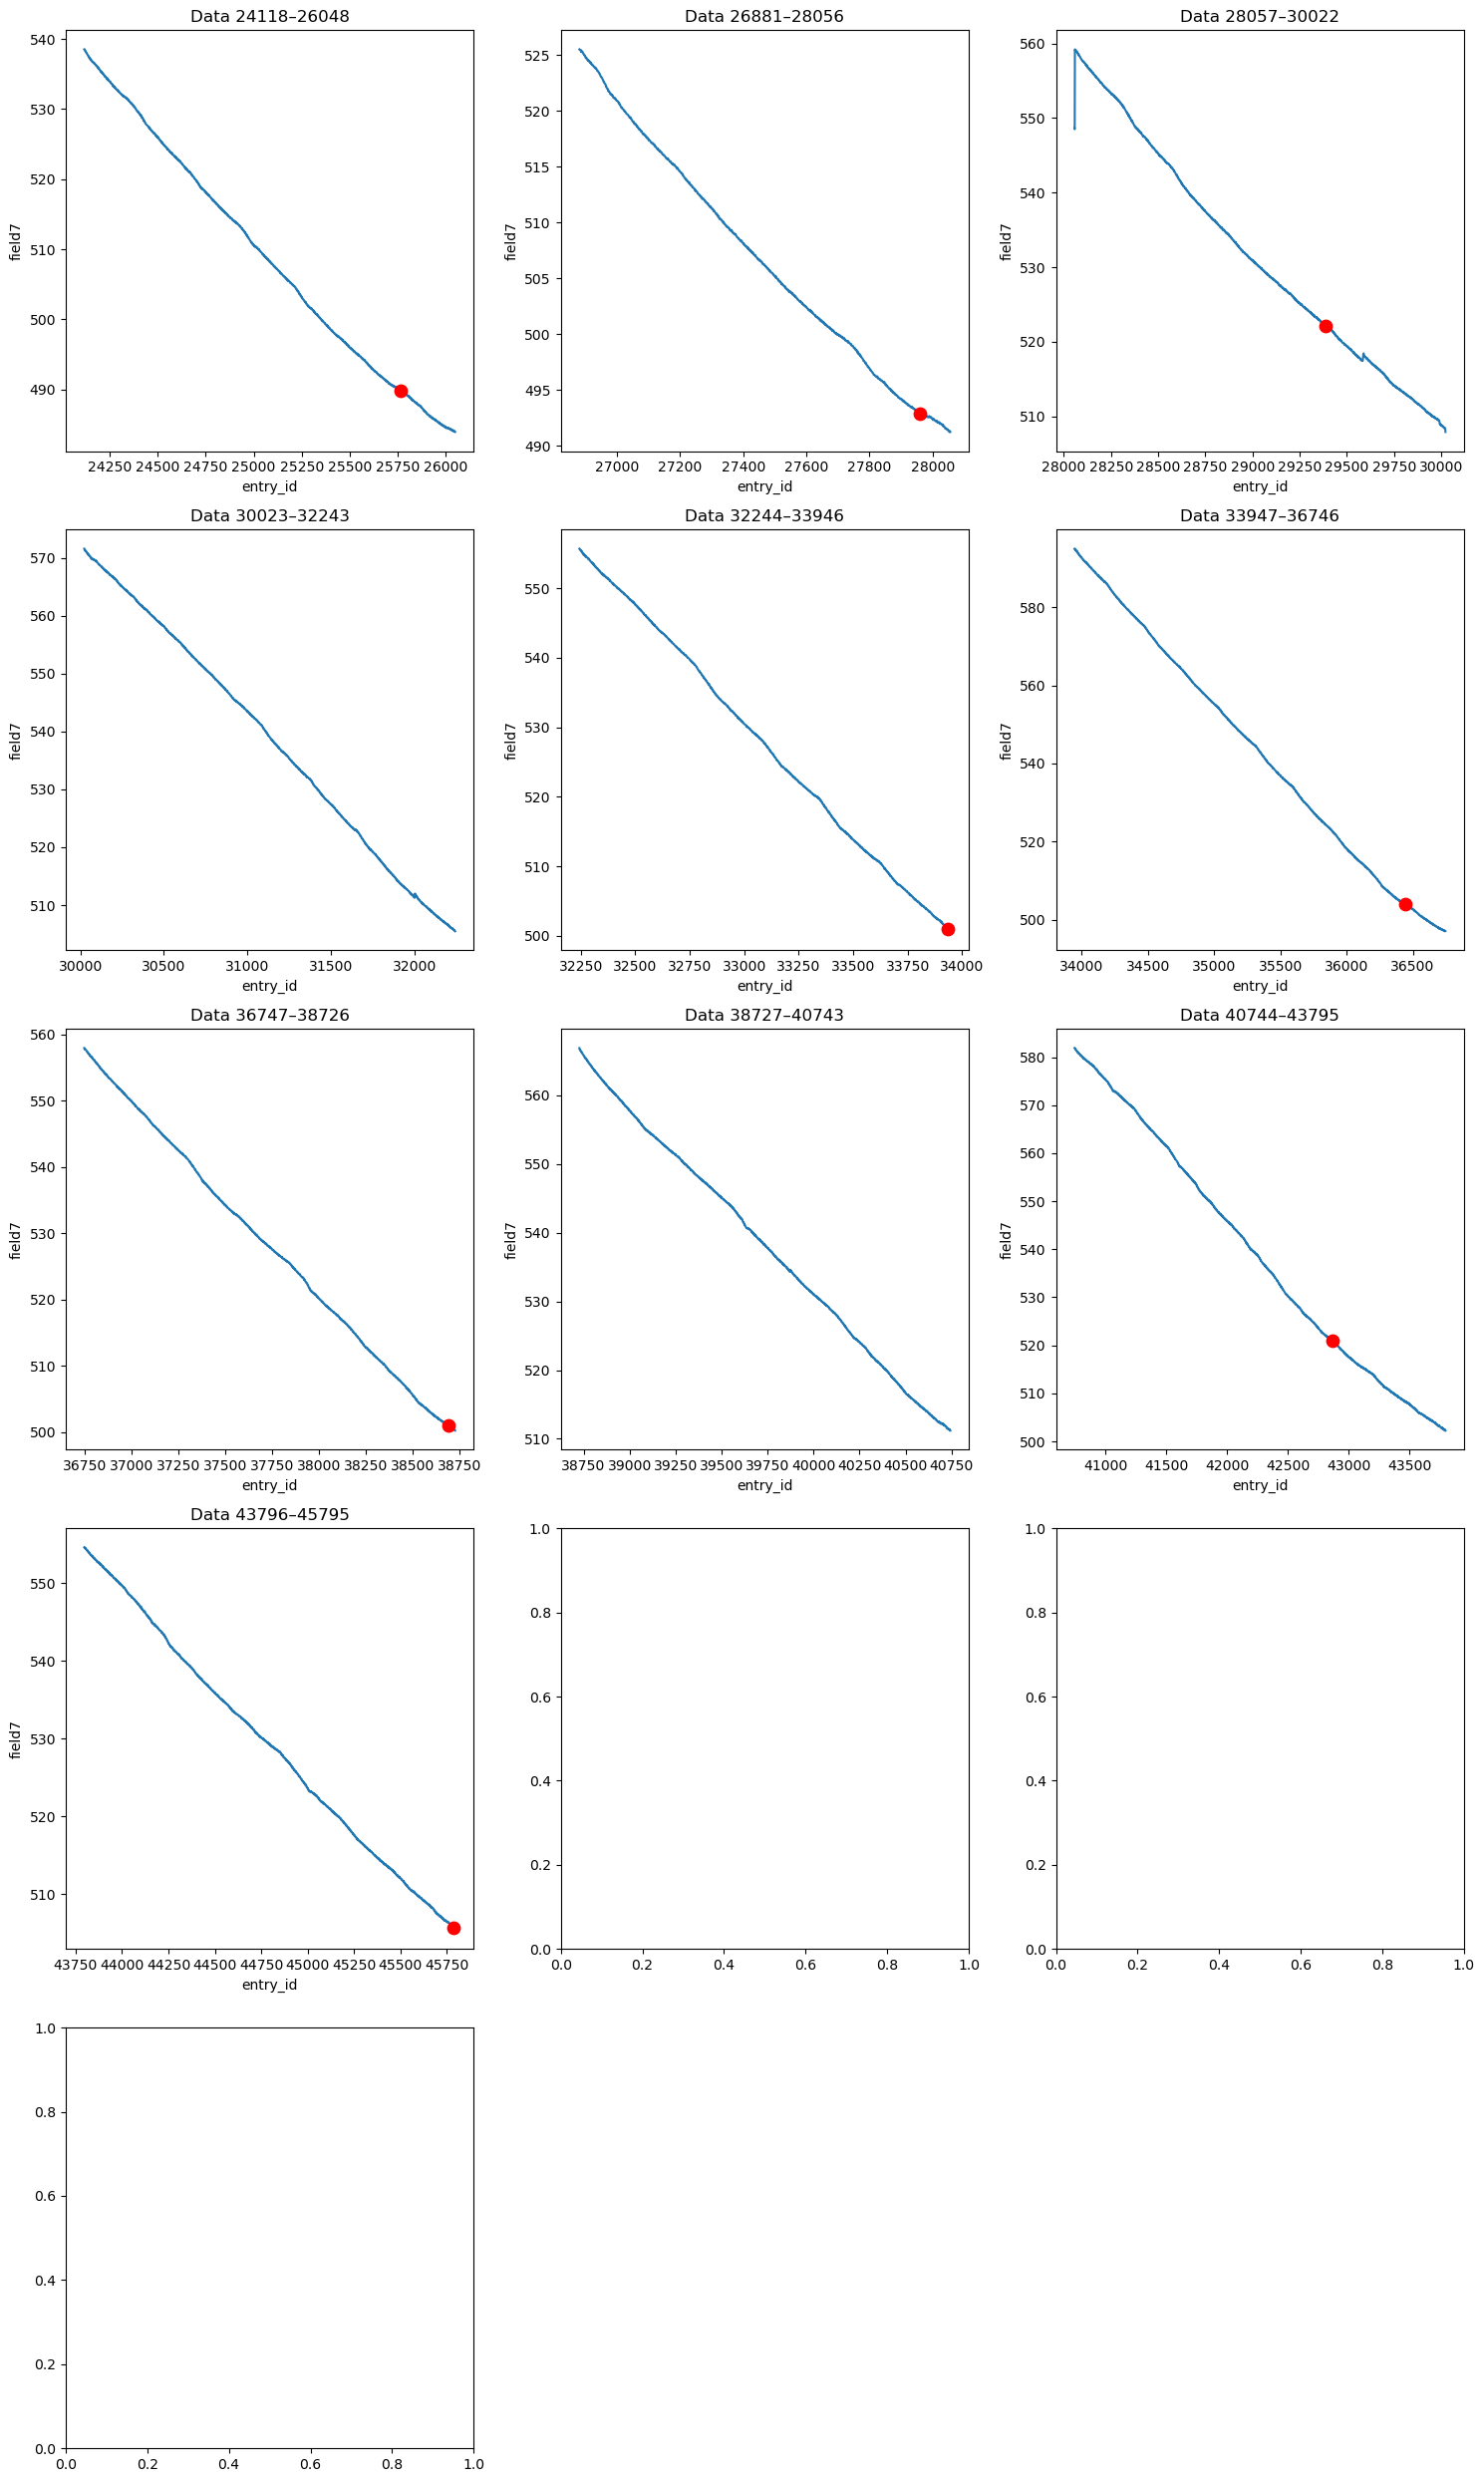

In [208]:

data = data_5

size = data.shape[0]
jump_val = 10
min_chunk_size = 5
jump_points = []

field = "field7"

# Find jump points
for i in range(size - 1):
    loc = data[field].iloc[i]
    nxt = data[field].iloc[i + 1]
    if abs(loc - nxt) > jump_val:
      if len(jump_points) == 0:
        jump_points.append(i + 1)
      elif i - jump_points[-1] >= min_chunk_size:
        jump_points.append(i + 1)

# Build list of (start, end) segments
segments = list(zip(jump_points[:-1], jump_points[1:]))
long_segments = []

for segment in segments:

    if segment[1]-segment[0] > 1000:
        long_segments.append(segment)
print(long_segments)

results = []
for segment in long_segments:
    lower_bound = data_5.iloc[segment[0]]["entry_id"]
    upper_bound = data_5.iloc[segment[1]]["entry_id"]
    print(lower_bound, upper_bound)
    #model_zero_points(data_5, lower_bound, upper_bound, field)
    #results.append(model_cusum(data_5, lower_bound, upper_bound, field))
    #model_avg_residual(data_5, lower_bound, upper_bound, field)
    results.append(model_Difference(data_5, field, lower_bound, upper_bound, 12))
results = list(filter(None, results))
# Determine subplot layout
n = len(segments)
cols = 3                        # you can change layout here
rows = (n + cols - 1) // cols   # ceiling division

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  # flatten in case of multi-row grid

for ax, (start, end) in zip(axes, long_segments):
    loc_data = data.iloc[start:end]
    min_entry_id = loc_data['entry_id'].min()
    max_entry_id = loc_data['entry_id'].max()

    # 2. Filter the global list down to IDs that are ONLY in this segment
    # We compare the ID value to the MIN/MAX entry_id of the current plot data
    segment_ids_to_highlight = [
    id_val for id_val in results
    if min_entry_id <= id_val <= max_entry_id
    ]

    ax.plot(loc_data["entry_id"], loc_data[field])
    
    if segment_ids_to_highlight:
        highlight_points = loc_data[loc_data['entry_id'].isin(segment_ids_to_highlight)]
        ax.scatter(
            highlight_points["entry_id"], 
            highlight_points[field], 
            color='red',           # Set the color to red
            marker='o',            # Use a simple circle
            s=80,                  # Set marker size
            zorder=5               # Plot on top
        )

    ax.set_title(f"Data {min_entry_id}–{max_entry_id}")
    ax.set_xlabel("entry_id")
    ax.set_ylabel(field)

# Hide unused subplots
for ax in axes[len(segments):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [207]:
#THis model's goal is to deduce when the plant should be watered by looking at the absolute changes in water loss
def model_Difference(data, field_nr, lower, upper, shift_amount):
    field = select_range(data, field_nr, lower, upper)
    field[field_nr] = (field[field_nr].shift(-shift_amount) - field[field_nr])
    field = field[field["entry_id"] % shift_amount == 0].copy()
    
    upperlimit = lower + 576
    #print((upper-upperlimit))
    min_mean = 0
    max_mean = -10000
    for i in range(shift_amount, (upper-upperlimit), shift_amount):

        current_field = field[field["entry_id"] < (upperlimit)].copy()
        
        range_length = 120 // shift_amount
        

        original_mean = 0
        
        for diff in current_field[field_nr].iloc[:range_length]:
            original_mean += diff
        original_mean /= range_length

       
        last_mean = 0

        for diff in current_field[field_nr].iloc[-range_length:]:
            last_mean += diff
        last_mean /= range_length

        if last_mean <original_mean and last_mean <min_mean:
            min_mean = last_mean
        elif original_mean <min_mean:
            min_mean = original_mean

        if last_mean > max_mean:
            max_mean = last_mean
 

        if max_mean * (7/4) > min_mean:
            
            print(upperlimit, "siin", upper-upperlimit)
            break
        
        upperlimit += shift_amount
    
    if upperlimit+1 != upper:
        return upperlimit


model_Difference(data_5, "field7", 26049, 28057, 12)


27693 siin 364


27693

In [216]:
#THis model's goal is to deduce when the plant should be watered by looking at the absolute changes in water loss and analysing the standard deviation, does not work
def model_Stdev(data, field_nr, lower, upper, shift_amount):
    field = select_range(data, field_nr, lower, upper)
    field[field_nr] = (field[field_nr].shift(-shift_amount) - field[field_nr])
    field = field[field["entry_id"] % shift_amount == 0].copy()
    
    upperlimit = lower + 576
    #print((upper-upperlimit))

    for i in range(shift_amount, (upper-upperlimit), shift_amount):

        current_field = field[field["entry_id"] < (upperlimit)].copy()
        
        range_length = 120 // shift_amount
        

        original_stdev = current_field[field_nr].iloc[:range_length].std()
        
        last_stdev = current_field[field_nr].iloc[-range_length:].std()
        print(last_stdev)
        if last_stdev * (0.5) > original_stdev:
            
            print(upperlimit, "siin", upper-upperlimit, last_stdev)
            break
        if upperlimit + 100 > upper:
            print(original_stdev, last_stdev)
        
        upperlimit += shift_amount
    
    if upperlimit+1 != upper:
        return upperlimit


model_Stdev(data_5, "field7", 26049, 28057, 12)


0.06118278625019777
0.056332347131441834
0.056332347131441834
0.06583649781427675
0.06446359868607722
0.060772800933776024
0.07393691004275103
26697 siin 1360 0.07393691004275103


26697